In [22]:
import torch
from torchvision import datasets, transforms
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pylab as plt
import numpy as np
import plotly.express as px

In [23]:
# -------------------------
# 1. Load MNIST
# -------------------------
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# -------------------------
# 2. Convert MNIST to pandas DataFrame
# -------------------------
def mnist_to_df(mnist_dataset):
    images = []
    labels = []

    for img, label in mnist_dataset:
        img = img.squeeze().numpy().reshape(28*28)   # 784 vector
        images.append(img)
        labels.append(label)

    df = pd.DataFrame(images)
    df['label'] = labels
    return df

train_df = mnist_to_df(mnist_train)
test_df  = mnist_to_df(mnist_test)

In [24]:
# -------------------------
# 3. Create X_train, y_train, X_test, y_test
# -------------------------
X_train = train_df.drop(columns=["label"]).values
y_train = train_df["label"].values

X_test = test_df.drop(columns=["label"]).values
y_test = test_df["label"].values

### Training on all the features (NO PCA)

In [25]:
knn = KNeighborsClassifier() 
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Accuracy Score : " , accuracy_score(y_test, y_pred))

Accuracy Score :  0.9688


#### Using PCA

In [26]:
scaler   = StandardScaler() 

X_train  = scaler.fit_transform(X_train)
X_test   = scaler.transform(X_test)

pca      = PCA(n_components=100)

X_train_trf  = pca.fit_transform(X_train)
X_test_trf   = pca.transform(X_test)

knn = KNeighborsClassifier()
knn.fit(X_train_trf, y_train)

y_pred       = knn.predict(X_test_trf)
print("Accuracy Score : " , accuracy_score(y_test, y_pred))

Accuracy Score :  0.9577


### Reducing the data to only 2D to plot it 

In [27]:
pca          = PCA(n_components=2)
X_train_trf  = pca.fit_transform(X_train)
X_test_trf   = pca.transform(X_test)

In [28]:
y_train_trf = y_train.astype(str)

fig = px.scatter(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

### Reducing the data to only #D to plot it 

In [29]:
pca          = PCA(n_components=3)
X_train_trf  = pca.fit_transform(X_train)
X_test_trf   = pca.transform(X_test)

In [30]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

y_train_trf = y_train.astype(str)

fig = px.scatter_3d(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],   # <-- Missing earlier
    color=y_train_trf,
)

fig.update_layout(margin=dict(l=20, r=20, t=20, b=20))
fig.show()


In [31]:
pca.explained_variance_     # gets the eigen value , These are the actual eigenvalues (not percentages).

array([40.48764 , 29.241682, 26.811766], dtype=float32)

In [32]:
print(pca.components_.shape)       # get the eigen vectors

(3, 784)



#### **How to Find the Optimum Number of Principal Components (PCs)**

#### **1. Compute PCA on the Full Dataset**

If the dataset has **784 columns**, PCA can generate a maximum of **784 Principal Components**.

```python
pca = PCA(n_components=None)
pca.fit(X)
```

This gives **all possible PCs**.

---

#### **2. Extract Eigenvalues**

```python
pca.explained_variance_
```

This returns **784 eigenvalues**:

* Each eigenvalue (λₖ) tells **how much variance** the corresponding principal component (PCₖ) explains in raw numerical form.
---

#### **3. Compute Variance Explained by Each PC**

```python
pca.explained_variance_ratio_
```

This returns **percentage variance explained** by each PC:

[
\text{Explained Variance Ratio} = \frac{\lambda_k}{\sum_{i=1}^{784} \lambda_i}
]

Example:

* PC1 → 0.32  (32%)
* PC2 → 0.20  (20%)
* PC3 → 0.12  (12%)

---

#### **4. Compute Cumulative Variance**

```python
np.cumsum(pca.explained_variance_ratio_)
```

This tells how much total variance is explained when you keep adding PCs:

| PC Count              | Cumulative Variance |
| --------------------- | ------------------- |
| PC1                   | 32%                 |
| PC1 + PC2             | 52%                 |
| PC1 + PC2 + PC3       | 64%                 |
| PC1 + PC2 + PC3 + PC4 | 74%                 |
| ...                   | ...                 |

---

#### **5. Determine the Optimum Number of PCs**

> **Choose the smallest number of PCs such that cumulative explained variance ≥ 90%.**

Example:

* If cumulative variance crosses **90% at PC = 120**,
  then **120 PCs** is the optimum dimensionality.

---

#### **Summary**

* `explained_variance_` → eigenvalues (λ)
* `explained_variance_ratio_` → λ / sum(λ) (percentage variance)
* `np.cumsum(...)` → cumulative variance
* **Stop when cumulative variance ≥ 90%**
* The number of PCs at this point = **optimal PCs**


In [33]:
pca          = PCA(n_components=None)
X_train_trf  = pca.fit_transform(X_train)
X_test_trf   = pca.transform(X_test)

In [34]:
pca.explained_variance_.shape

(784,)

In [35]:
pca.components_.shape

(784, 784)

In [36]:
pca.explained_variance_ratio_     

array([5.64671382e-02, 4.07827385e-02, 3.73938158e-02, 2.88511254e-02,
       2.52110455e-02, 2.19427049e-02, 1.92334503e-02, 1.74580030e-02,
       1.53509332e-02, 1.40171973e-02, 1.34174339e-02, 1.20374234e-02,
       1.11457016e-02, 1.08992448e-02, 1.02864858e-02, 9.94485617e-03,
       9.36383661e-03, 9.21045896e-03, 8.93437490e-03, 8.69912189e-03,
       8.27362668e-03, 8.03416967e-03, 7.64845684e-03, 7.41772866e-03,
       7.15292944e-03, 6.91846851e-03, 6.84136059e-03, 6.56674802e-03,
       6.31676707e-03, 6.12919638e-03, 5.96255204e-03, 5.87716512e-03,
       5.71591826e-03, 5.62307565e-03, 5.54681290e-03, 5.38418489e-03,
       5.31182345e-03, 5.19605679e-03, 5.08210948e-03, 4.80005518e-03,
       4.76455968e-03, 4.69139032e-03, 4.54348838e-03, 4.51345649e-03,
       4.46963264e-03, 4.43383073e-03, 4.38215304e-03, 4.30381764e-03,
       4.26877802e-03, 4.23647044e-03, 4.04695654e-03, 3.99447279e-03,
       3.97456111e-03, 3.93820414e-03, 3.85813322e-03, 3.79042467e-03,
      

In [37]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05646714, 0.09724988, 0.1346437 , 0.16349483, 0.18870588,
       0.21064858, 0.22988203, 0.24734004, 0.26269096, 0.27670816,
       0.29012558, 0.302163  , 0.31330872, 0.32420796, 0.33449444,
       0.3444393 , 0.35380313, 0.3630136 , 0.37194797, 0.3806471 ,
       0.38892072, 0.3969549 , 0.40460336, 0.4120211 , 0.41917402,
       0.42609248, 0.43293384, 0.43950057, 0.44581735, 0.45194656,
       0.4579091 , 0.46378627, 0.46950218, 0.47512525, 0.48067206,
       0.48605624, 0.49136806, 0.49656412, 0.5016462 , 0.5064463 ,
       0.51121086, 0.5159022 , 0.5204457 , 0.52495915, 0.5294288 ,
       0.5338626 , 0.5382447 , 0.54254854, 0.5468173 , 0.55105376,
       0.55510074, 0.5590952 , 0.56306976, 0.56700796, 0.5708661 ,
       0.57465655, 0.57841057, 0.58211833, 0.58576775, 0.5893608 ,
       0.5928846 , 0.59636253, 0.59980667, 0.6032053 , 0.6065649 ,
       0.60991377, 0.6132324 , 0.61646265, 0.6196254 , 0.62275785,
       0.62586516, 0.6289376 , 0.63198674, 0.63501394, 0.63800

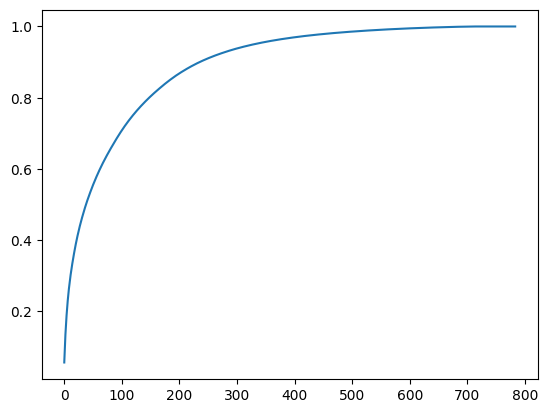

In [38]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

#### Between 300 to 400 will be a good PC to be considered